In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
import sklearn.linear_model
import rasterio
import PIL.Image
from tqdm import tqdm

In [2]:
DIRECTORY = pathlib.Path("~/storage/data/oaec-found-gully").expanduser()

In [3]:
PIL.Image.MAX_IMAGE_PIXELS = None  # I know my images are large; they're not DoS attacks...

In [4]:
names = {
    "pepperwood": "Big Pepperwood Creek",
    "dutch": "Dutch Bill Creek",
    "flat": "Flat Ridge Creek Buckeye",
    "kolmer": "Kolmer Gulch",
    "drylow": "Lower Dry Creek Lower",
    "dry": "Lower Dry Creek",
    "salmon": "Lower Salmon Creek",
    "tombs": "Tombs Creek",
    "sulphur": "Upper Big Sulphur Creek",
    "matanzas": "Upper Matanzas Creek",
}

truth = []
metrics = {
    "min15": [],
    "max15": [],
    "low15": [],
    "highlow15": [],
    "min5": [],
    "max5": [],
    "low5": [],
    "highlow5": [],
}

for name in tqdm(names):
    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
        mask = np.asarray(file)[:, :, 1] < 128

    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
        gully = np.asarray(file)[:, :, 1] > 128

    for metric in metrics:
        with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
            data = file.read(1)
        np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
        metrics[metric].append(data[mask])
        del data

    truth.append(gully[mask])
    del mask
    del gully

100%|███████████████████████████████████████████████████████████████| 10/10 [01:32<00:00,  9.29s/it]


In [5]:
slices = []
start = 0
for name, array in zip(names, truth):
    stop = start + len(array)
    slices.append(slice(start, stop))
    start = stop

alltruth = np.concatenate(truth)
allmetrics = {metric: np.concatenate(arrays) for metric, arrays in metrics.items()}

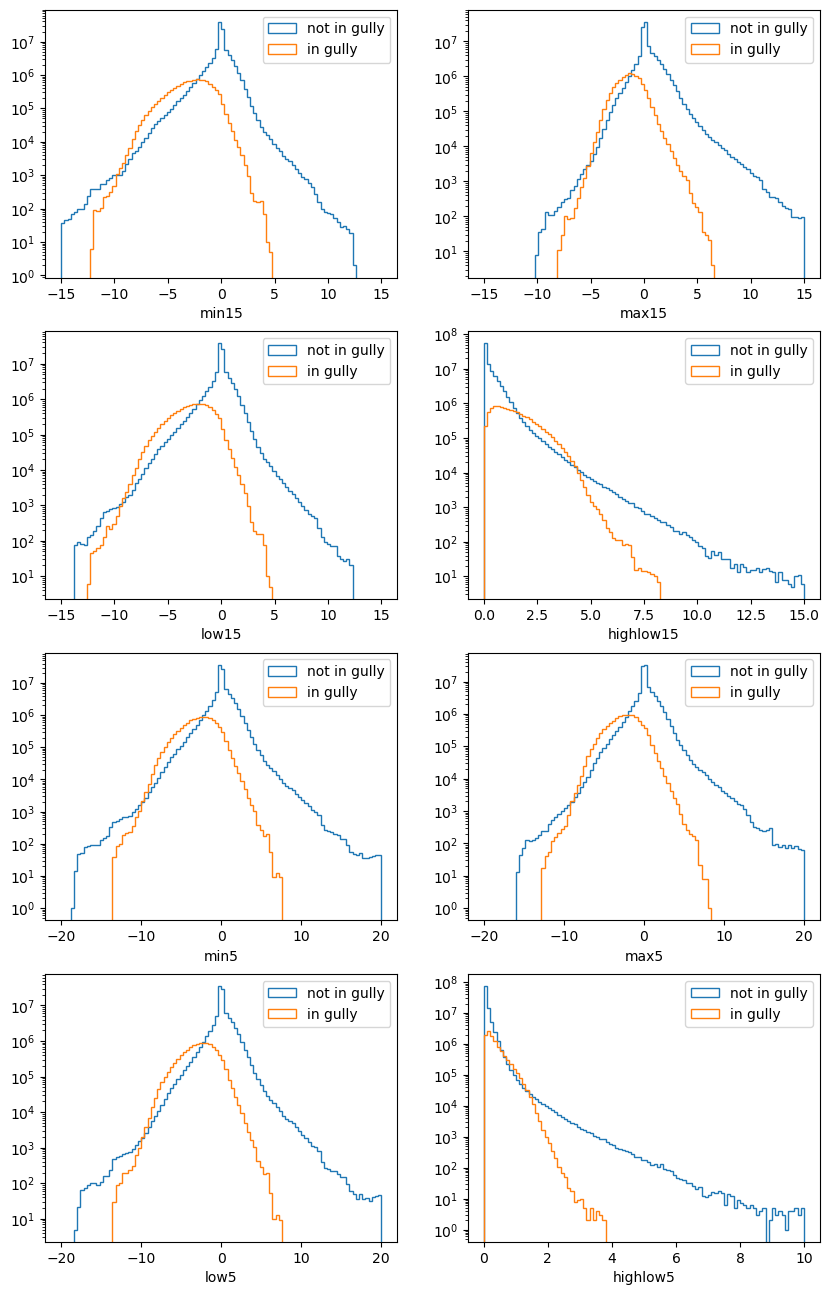

In [6]:
fig, axs = plt.subplots(4, 2, figsize=(10, 16))

ranges = {
    "min15": (-15, 15),
    "max15": (-15, 15),
    "low15": (-15, 15),
    "highlow15": (0, 15),
    "min5": (-20, 20),
    "max5": (-20, 20),
    "low5": (-20, 20),
    "highlow5": (0, 10),
}

for ax, metric in zip(axs.flatten(), metrics):
    ax.hist(allmetrics[metric][~alltruth], bins=100, range=ranges[metric], histtype="step", label="not in gully")
    ax.hist(allmetrics[metric][alltruth], bins=100, range=ranges[metric], histtype="step", label="in gully")

    ax.legend()
    
    ax.set_yscale("log")
    ax.set_xlabel(metric)

None

In [7]:
del truth
del metrics

features = [
    "min15",
    "max15",
    "low15",
    "highlow15",
    "min5",
    "max5",
    "low5",
    "highlow5",
    "low15 * highlow15",
    "low15 * highlow5",
    "low5 * highlow15",
    "low5 * highlow5",
]

X = np.stack([
    allmetrics["min15"],
    allmetrics["max15"],
    allmetrics["low15"],
    allmetrics["highlow15"],
    allmetrics["min5"],
    allmetrics["max5"],
    allmetrics["low5"],
    allmetrics["highlow5"],
    allmetrics["low15"] * allmetrics["highlow15"],
    allmetrics["low15"] * allmetrics["highlow5"],
    allmetrics["low5"] * allmetrics["highlow15"],
    allmetrics["low5"] * allmetrics["highlow5"],
]).T
Y = alltruth

del allmetrics
del alltruth

In [8]:
fit = sklearn.linear_model.LogisticRegression(penalty="l2", C=np.inf)
fit.fit(X, Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,inf
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
for feature, parameter in zip(features, fit.coef_[0]):
    print(f"{feature:25s} {parameter:9.6f}")

print(f"\n{'(intercept)':25s} {fit.intercept_[0]:9.6f}")

min15                     -3.055403
max15                     -1.074228
low15                     -0.979766
highlow15                  1.811156
min5                       0.971579
max5                       0.844754
low5                       1.186560
highlow5                  -0.103141
low15 * highlow15          1.721205
low15 * highlow5          -0.282670
low5 * highlow15          -1.211754
low5 * highlow5            0.381563

(intercept)               -4.653235


In [10]:
test_samples = np.stack([np.random.uniform(-10, 10, 1000) for _ in features]).T

predictions = fit.predict_proba(test_samples)[:, 1]

def logistic(x):
    return 1/(1 + np.exp(-x))

for test_sample, prediction in zip(test_samples, predictions):
    assert logistic(fit.coef_ @ test_sample.T + fit.intercept_) == prediction

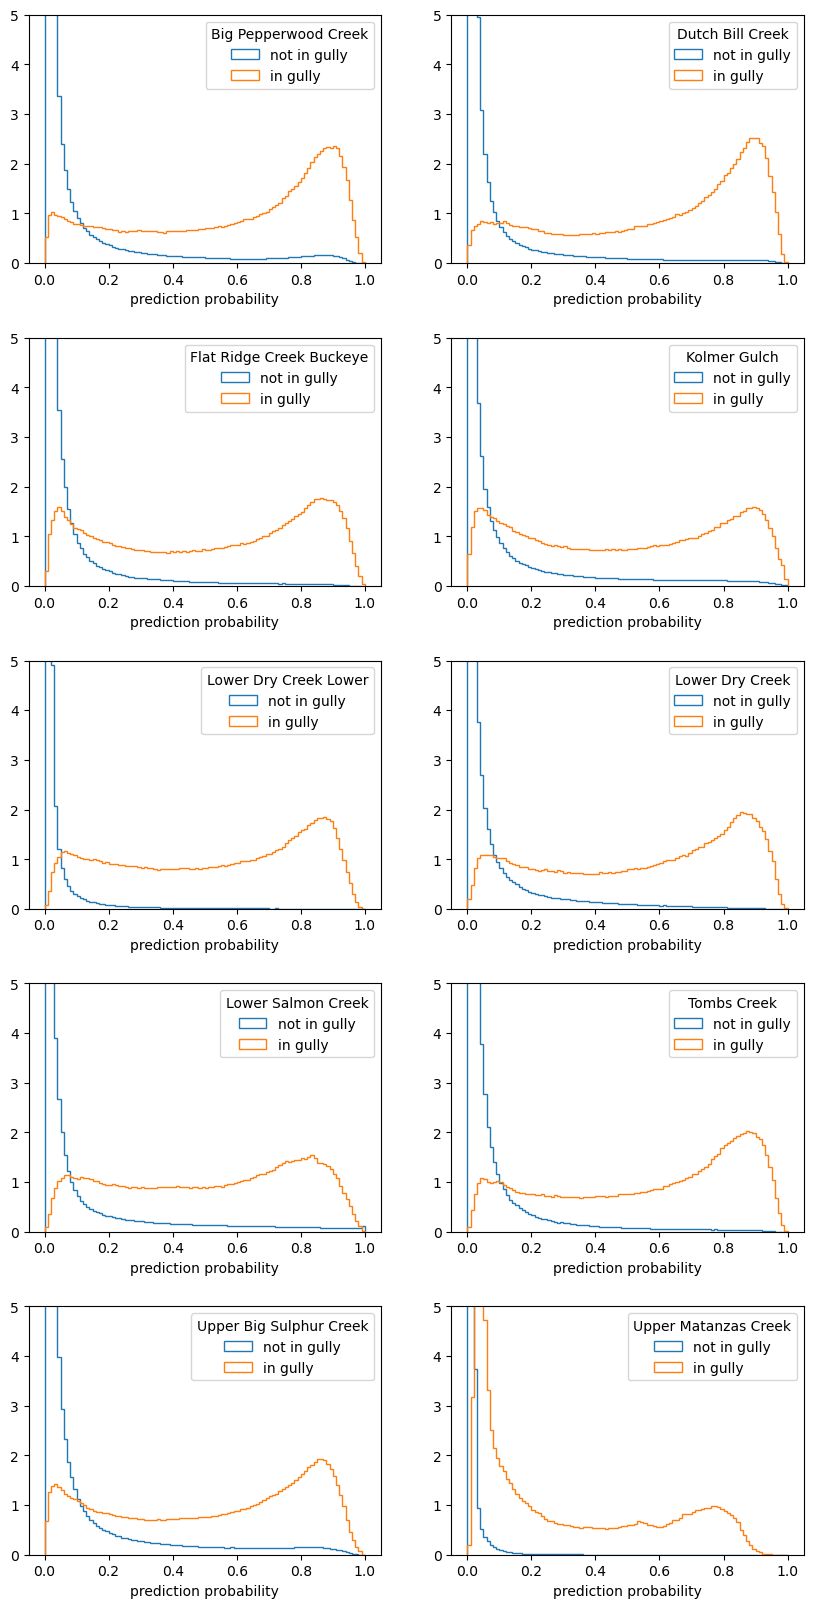

In [11]:
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for ax, name, slc in zip(axs.flatten(), names, slices):
    ax.hist(fit.predict_proba(X[slc][~Y[slc]])[:, 1], bins=100, range=(0, 1), density=True, histtype="step", label="not in gully")
    ax.hist(fit.predict_proba(X[slc][Y[slc]])[:, 1], bins=100, range=(0, 1), density=True, histtype="step", label="in gully")

    ax.legend(loc="upper right", title=names[name])

    ax.set_ylim(0, 5)
    ax.set_xlabel("prediction probability")

plt.subplots_adjust(hspace=0.3)

None

In [12]:
name = "matanzas"

In [13]:
with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
    mask = np.asarray(file)[:, :, 1] < 128

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
    gully = (np.asarray(file)[:, :, 1] > 128).astype(np.float32)

gully[~mask] = np.nan

metrics = {
    "min15": None,
    "max15": None,
    "low15": None,
    "highlow15": None,
    "min5": None,
    "max5": None,
    "low5": None,
    "highlow5": None,
}
for metric in metrics:
    with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
        data = file.read(1)
    np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
    metrics[metric]= data

In [14]:
X_test = np.stack([
    metrics["min15"],
    metrics["max15"],
    metrics["low15"],
    metrics["highlow15"],
    metrics["min5"],
    metrics["max5"],
    metrics["low5"],
    metrics["highlow5"],
    metrics["low15"] * metrics["highlow15"],
    metrics["low15"] * metrics["highlow5"],
    metrics["low5"] * metrics["highlow15"],
    metrics["low5"] * metrics["highlow5"],
]).transpose(1, 2, 0)

assert not np.isnan(X_test[mask]).any()
X_test[np.isnan(X_test)] = 0

In [15]:
probability = fit.predict_proba(X_test.reshape(-1, len(features)))[:, 1].reshape(mask.shape)
probability[~mask] = np.nan

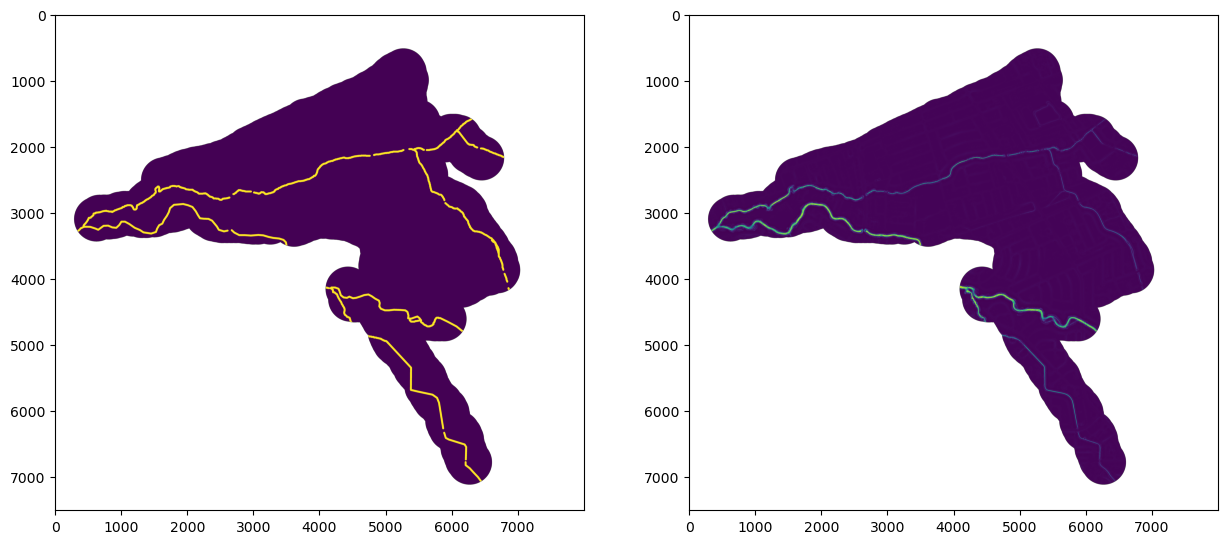

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

ax1.imshow(gully[1000:8500, 0:8000])
ax2.imshow(probability[1000:8500, 0:8000])

None